<a href="https://colab.research.google.com/github/Annesya/vcca-tutorial-periphery/blob/main/model_of_auditory_periphery_simplified_w_comments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

================================================================================
VCCA 2026 Tutorial: computational models of auditory periphery: from normal to impairment
================================================================================

This script is a simplified, pedagogical auditory-periphery model. It takes an
acoustic waveform and pushes it through a sequence of computational stages that
roughly mirror early biological hearing:

    sound waveform
        -> cochlear frequency analysis with a gammatone filterbank
        -> inner-hair-cell-like rectification
        -> inner-hair-cell-like low-pass filtering / phase-locking limitation
        -> auditory-nerve rate-level nonlinearities
        -> stochastic spike-count generation
        -> nervegram visualization

The comments are written for a broad audience. The main idea is that each block
turns the sound into a representation that is closer to what the auditory nerve
might send to the brain.

Important simplification:
    This is not a full biophysical model of the ear. It is a useful teaching
    model that captures several core signal-processing ideas: frequency tuning,
    envelope extraction, nonlinear compression / saturation, different fiber
    populations, and stochastic neural firing.

In [ ]:
!git clone https://github.com/Annesya/vcca-tutorial-periphery.git
%cd vcca-tutorial-periphery
!ls -l

In [1]:
# =============================================================================
# Imports
# =============================================================================
# glob, os, and sys are general utilities for locating files and interacting with
# the runtime environment. They are not specific to hearing, but they help the
# notebook find audio files and supporting modules.
import glob
import os
import sys

# IPython.display lets a notebook play audio inline. This is useful because the
# first step in any auditory model should be listening to the stimulus whenever
# possible.
import IPython.display as ipd

# matplotlib is used throughout the tutorial to visualize the sound waveform,
# spectrogram, filter responses, intermediate model signals, firing rates, and
# the final nervegram.
import matplotlib.pyplot as plt

# numpy handles ordinary array operations on CPU. Here it is mostly used for
# plotting axes, converting tensors to arrays, and making simple example inputs.
import numpy as np

# soundfile is commonly used for reading/writing audio. The current script uses
# torchaudio for loading, but soundfile may be useful in nearby tutorial cells.
import soundfile as sf

# torch is the main numerical backend. Treat the auditory model as a series of
# differentiable signal-processing layers, similar to layers in a neural network.
import torch

# torchaudio loads the sound file into a PyTorch tensor. A tensor is just a
# multidimensional array that PyTorch can process efficiently on CPU or GPU.
import torchaudio

# tqdm provides progress bars. It is imported here for convenience, even though
# this simplified script does not use it heavily.
import tqdm


# =============================================================================
# Runtime setup
# =============================================================================
# The current working directory tells us where the notebook or Python process is
# running. This is useful for debugging missing files, such as utils.py,
# modules.py, or the example audio file.
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# NOTE FOR USERS RUNNING THIS AS A PLAIN .py FILE:
#   The original Colab export used: !ls -F
#   The leading ! is valid in a notebook cell, but it is not valid Python syntax
#   in a normal script. os.system("ls -F") does the same directory listing in a
#   way that works in a regular Python file.
os.system("ls -F")

# These two local modules contain the tutorial-specific model components and
# plotting helpers. They are where classes such as GammatoneFilterbank,
# IHCLowpassFilter, and SigmoidRateLevelFunction are defined.
import utils
import modules

Current working directory: /content


# Generate an example audio signal

In [3]:
# =============================================================================
# 1. Load the acoustic stimulus
# =============================================================================
# The input to the auditory periphery is a pressure waveform: air pressure as a
# function of time. In this tutorial, the example is speech mixed with noise.
#
# A real ear does not receive a spectrogram or a feature vector; it receives this
# time-domain waveform at the eardrum. Everything below asks: how might the
# cochlea, hair cells, and auditory nerve transform that waveform?
audio_file_path = '/content/example_speech_in_noise.wav'
waveform, sample_rate = torchaudio.load(audio_file_path)

# torchaudio returns waveform with shape [channels, time_samples].
# For a mono file, this is usually [1, number_of_samples].
# sample_rate tells us how many samples per second are in the waveform.
print(f"Waveform shape: {waveform.shape}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {waveform.shape[-1] / sample_rate:.2f} seconds")

# Play the stimulus in the notebook. Listening is pedagogically important:
# later visualizations should be connected back to what the sound actually
# sounds like.
import IPython.display as ipd
ipd.Audio(audio_file_path, rate=sample_rate)

Waveform shape: torch.Size([1, 40000])
Sample rate: 20000 Hz
Duration: 2.00 seconds


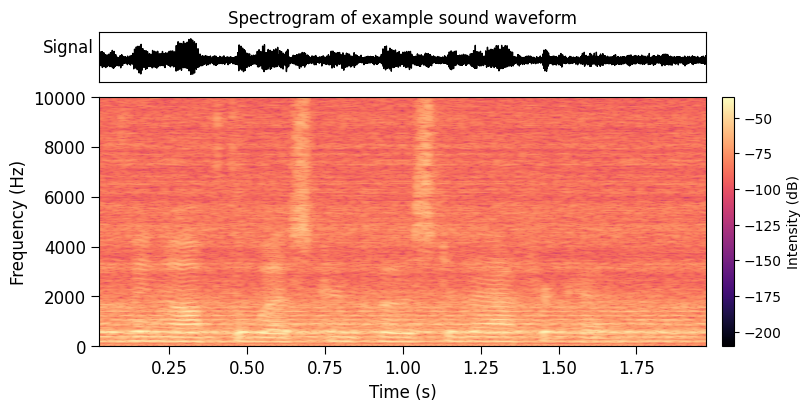

In [4]:
# A spectrogram is not itself the model. It is a familiar analysis plot that
# shows how energy is distributed across time and frequency. It gives us a
# human-readable preview of what the cochlear filterbank will later compute in a
# more biologically motivated way.
fig, ax = utils.make_spectrogram_plot(
    waveform.numpy()[0, :],
    sample_rate,
    figsize=(8, 4),
    # nfft=512,
    # noverlap=256,
    str_title="Spectrogram of example sound waveform",
)
plt.show()

# Define auditory periphery model parameters

In [5]:
# =============================================================================
# 2. Define parameters for the simplified auditory-periphery model
# =============================================================================
# These parameters define the model's assumptions about the cochlea, inner hair
# cell processing, and auditory nerve fibers. In a full research model, many of
# these values would be chosen to match physiological measurements.

# -----------------------------------------------------------------------------
# Auditory filterbank parameters
# -----------------------------------------------------------------------------
# The cochlea is tonotopically organized: different places along the basilar
# membrane respond best to different frequencies. Computationally, we approximate
# this with a bank of bandpass filters.

# Lowest characteristic frequency represented by the model, in Hz.
# This is the lowest "best frequency" among the simulated cochlear channels.
lowest_CF = 60

# Highest characteristic frequency represented by the model, in Hz.
# This upper limit is useful for speech and many everyday sounds, although human
# hearing can extend higher in young normal-hearing listeners.
highest_CF = 8000

# Number of cochlear channels. More channels give finer frequency resolution but
# also increase computation and make plots denser.
num_CFs = 50

# Bandwidth multiplier for the auditory filters. A value of 1 means the filters
# use their default bandwidth. Increasing it would make filters broader and less
# frequency selective; decreasing it would make filters narrower.
filter_bandwidth = 1

# -----------------------------------------------------------------------------
# Inner hair cell low-pass filter for phase locking
# -----------------------------------------------------------------------------
# Inner hair cells and auditory-nerve fibers can follow the fine timing of low
# frequency sounds, but this phase locking becomes weaker at high frequencies.
# A low-pass filter is a simple way to model this biological limitation.

# Duration of the finite impulse response filters used in the model.
# 0.05 seconds = 50 ms. Longer filters can implement sharper frequency responses
# but require more computation and introduce more temporal extent.
dur_impulse_response = 0.05  # 50 ms

# Approximate cutoff frequency, in Hz, above which phase-locked temporal fine
# structure is strongly attenuated in this simplified IHC stage.
phaselock_cutoff = 3000

# -----------------------------------------------------------------------------
# Auditory nerve fiber parameters
# -----------------------------------------------------------------------------
# Auditory nerve fibers are often grouped by spontaneous firing rate:
#   HSR: high spontaneous rate fibers
#   MSR: medium spontaneous rate fibers
#   LSR: low spontaneous rate fibers
#
# These groups differ in how active they are without sound, how sensitive they
# are to quiet sounds, and how wide a range of sound levels they can encode.
# This diversity helps the auditory nerve represent sounds across a large range
# of intensities.

# High spontaneous rate fibers:
# These fire often even in quiet. They tend to be sensitive to low-level sounds
# but saturate over a relatively small level range.
rate_spont_hsr = 70.0       # baseline firing rate in spikes/s
rate_max_hsr = 250.0        # approximate upper firing rate in spikes/s
threshold_hsr = 0.0         # lower threshold relative to the other groups
dynamic_range_hsr = 20.0    # level range over which the rate grows strongly
n_fiber_hsr = 384           # number of simulated fibers in this population

# Medium spontaneous rate fibers:
# These have lower baseline activity, higher threshold, and a broader dynamic
# range than HSR fibers.
rate_spont_msr = 4.0
rate_max_msr = 250.0
threshold_msr = 12.0
dynamic_range_msr = 40.0
n_fiber_msr = 160

# Low spontaneous rate fibers:
# These fire very little in quiet. They often require stronger sounds to respond,
# but they are useful for representing high-level sounds because they do not
# saturate as quickly.
rate_spont_lsr = 0.1
rate_max_lsr = 250.0
threshold_lsr = 28.0
dynamic_range_lsr = 80.0
n_fiber_lsr = 96

# The sigmoid rate-level function uses this fraction to define how much of the
# transition from spontaneous rate to maximum rate is covered by the specified
# dynamic range. For example, 0.95 means the dynamic range spans most of the
# rising part of the sigmoid.
dynamic_range_interval = 0.95

# Use the GPU if available. This is helpful because the model applies many
# filters and nonlinearities across many time samples and channels. The model
# also runs on CPU if no GPU is present.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Obtain the auditory subbands using a filterbank

In [11]:
# =============================================================================
# 3. Cochlear frequency analysis: gammatone filterbank
# =============================================================================
# This block approximates the frequency-selective mechanical response of the
# cochlea. Each filter represents a place on the basilar membrane tuned to a
# different characteristic frequency (CF). The output is a set of subband
# waveforms, one per simulated cochlear location.

# Generate the characteristic frequencies on an ERB-like scale. ERB spacing is
# commonly used in auditory modeling because cochlear filters are not evenly
# spaced on a linear frequency axis. Frequency resolution is relatively fine at
# low frequencies and coarser at high frequencies.
cfs = utils.erbspace(lowest_CF, highest_CF, num_CFs)

# Construct the filterbank. A gammatone filter is a standard auditory filter
# shape often used as a simple approximation to cochlear tuning.
#
# Key idea:
#   One input waveform goes in.
#   num_CFs filtered waveforms come out.
# Each output channel emphasizes sound energy near its own CF.
filterbank = modules.GammatoneFilterbank(
    sr=sample_rate,
    fir_dur=dur_impulse_response,
    cfs=cfs,
    dtype=torch.float32,
    bw_mult=1,
)
filterbank = filterbank.to(device)

# torch.fft lets us inspect the filters in the frequency domain. This is for
# visualization only: the actual filtering operation is performed by the
# filterbank object.
import torch.fft as fft

# Extract the finite impulse response (FIR) coefficients of the filterbank.
# An FIR filter is represented by a short time-domain waveform. Convolving the
# stimulus with this waveform produces the filtered output.
fir_weights = filterbank.fir.detach().cpu()

# Some implementations store filters with an extra singleton dimension. Squeezing
# removes that unnecessary dimension so the array is easier to plot as
# [filter_channel, filter_time].
if fir_weights.ndim == 3:
    fir_weights = fir_weights.squeeze(1)

# Compute each filter's magnitude response by taking the real FFT of the FIR
# coefficients. The magnitude response tells us which frequencies each cochlear
# channel passes or attenuates.
n_fft = 2048
freq_response = fft.rfft(fir_weights, n=n_fft)

# Convert linear magnitude to decibels. The small 1e-12 offset prevents log(0),
# which would otherwise produce negative infinity.
magnitude_db = 20 * torch.log10(torch.abs(freq_response) + 1e-12)

# Frequency axis for plotting the FFT bins from 0 Hz to Nyquist frequency
# (sample_rate / 2). Digital signals cannot represent frequencies above Nyquist.
freqs = torch.linspace(0, sample_rate / 2, magnitude_db.shape[-1])


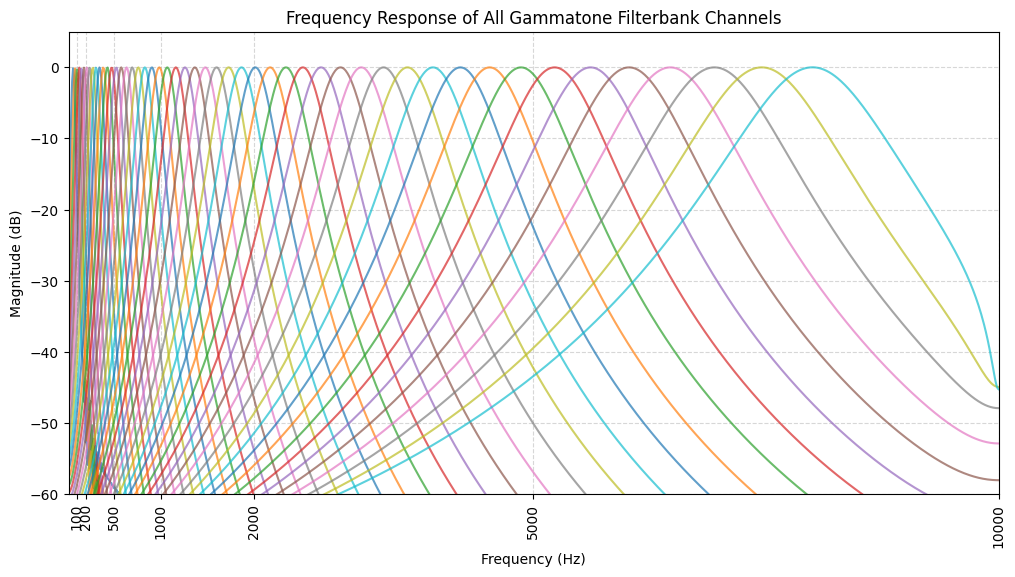

In [15]:
# The same filter responses on a linear-frequency axis. This view highlights how
# much of the horizontal space is occupied by high frequencies. Comparing log and
# linear views is useful for explaining why auditory frequency scales are often
# nonlinear.
plt.figure(figsize=(12, 6))
for i in range(num_CFs):
    plt.plot(freqs, magnitude_db[i, :], alpha=0.7)

plt.title('Frequency Response of All Gammatone Filterbank Channels')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.ylim(-60, 5)
plt.xlim(10, 10000)

ticks = [100, 200, 500, 1000, 2000, 5000, 10000]
plt.xticks(ticks, labels=[str(t) for t in ticks], rotation=90)

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()


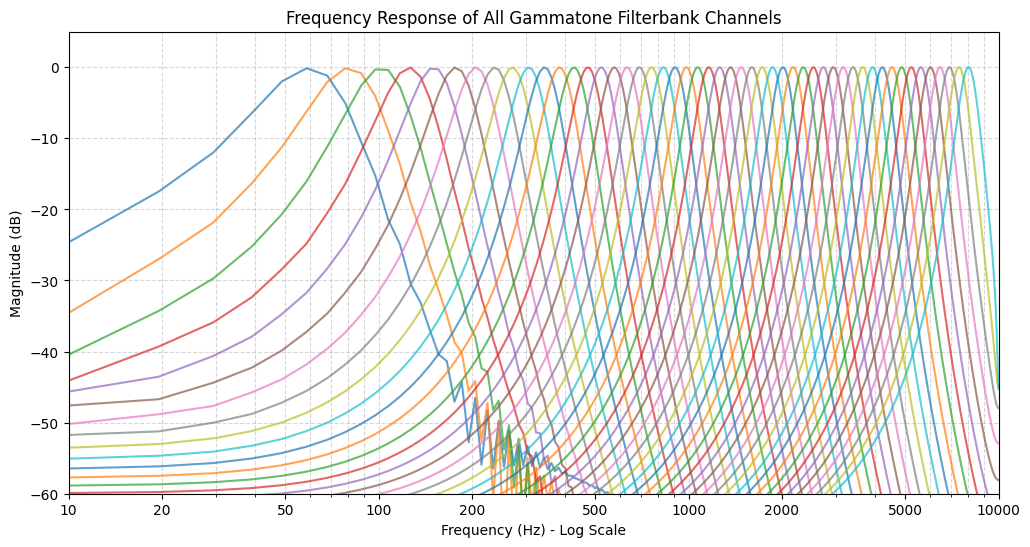

In [16]:
# Plot frequency responses on a log-frequency axis. This is the most intuitive
# view for hearing because pitch perception and cochlear spacing are closer to
# logarithmic than linear.
plt.figure(figsize=(12, 6))
for i in range(num_CFs):
    # Each curve shows one cochlear channel. Its peak is near that channel's CF.
    plt.plot(freqs, magnitude_db[i, :], alpha=0.7)

plt.xscale('log')
plt.title('Frequency Response of All Gammatone Filterbank Channels')
plt.xlabel('Frequency (Hz) - Log Scale')
plt.ylabel('Magnitude (dB)')
plt.ylim(-60, 5)
plt.xlim(10, 10000)

# Ticks at familiar frequencies make the log axis easier to interpret.
ticks = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
plt.xticks(ticks, labels=[str(t) for t in ticks])

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

Subbands shape: (1, 50, 40000)


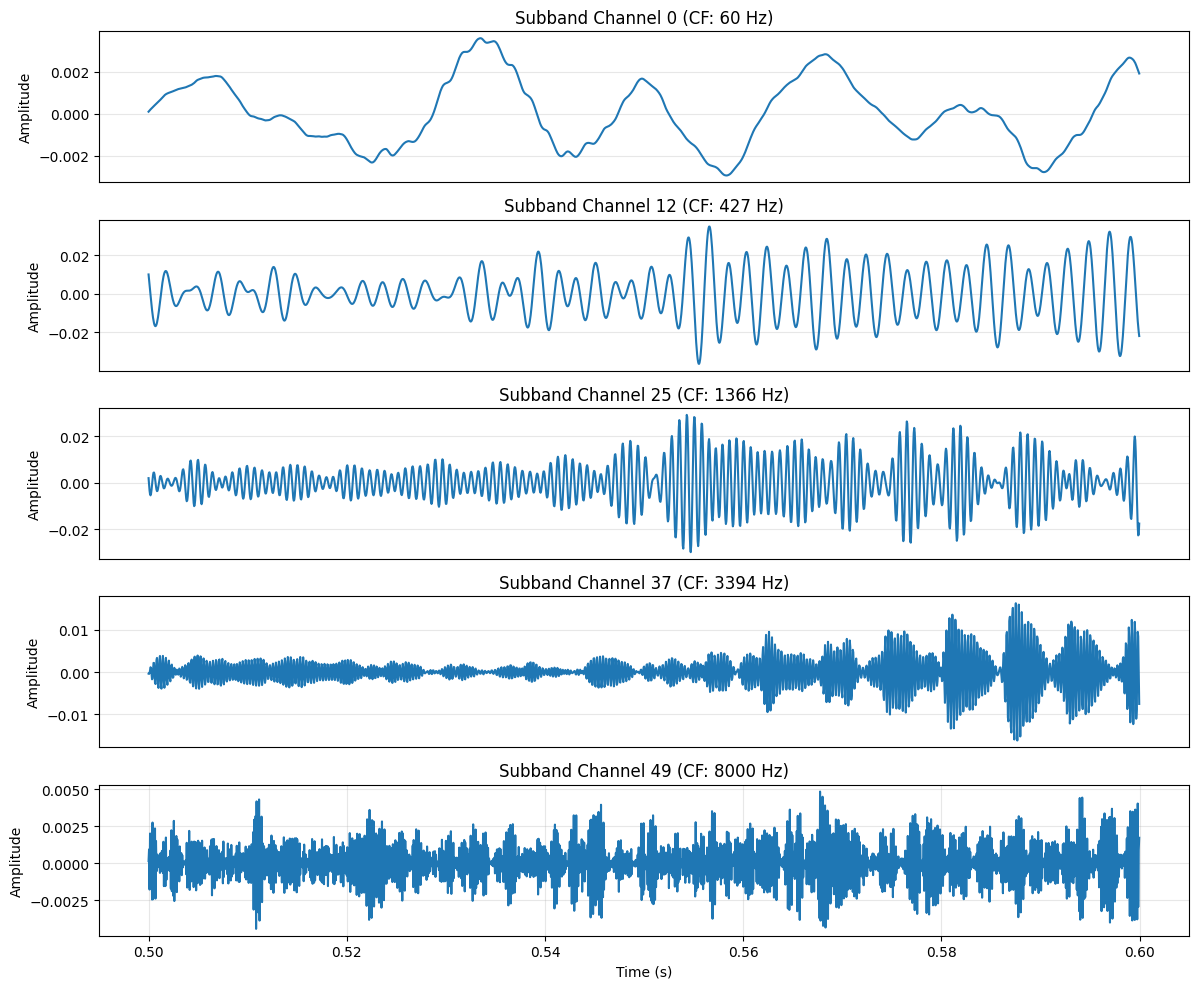

In [17]:
# Apply the cochlear filterbank to the waveform.
#
# Shape convention:
#   waveform from torchaudio: [audio_channel, time]
#   model expects:           [batch, audio_channel, time]
#
# batch is a machine-learning convention: it lets the same model process many
# sounds at once. Here there is only one sound, so batch size is 1.
waveform_device = waveform.unsqueeze(0).to(device)

with torch.no_grad():
    # subbands shape will be approximately [batch, num_CFs, time].
    # This is the first model-internal auditory representation: a time signal at
    # each simulated cochlear place.
    subbands = filterbank(waveform_device)

# Move data back to CPU and convert to NumPy for plotting. This does not change
# the model result; it only makes the data easier to visualize with matplotlib.
subbands_np = subbands.squeeze(0).cpu().numpy()
time_axis = np.arange(waveform.shape[-1]) / sample_rate

print(f"Subbands shape: {subbands_np.shape}")

# Re-imports are not necessary because numpy and matplotlib were imported above,
# but they are harmless in a notebook. They may have been included by the Colab
# export process.
import numpy as np
import matplotlib.pyplot as plt

# Ensure subbands_np is 2D: [num_channels, time].
# Depending on the implementation, there may be extra singleton dimensions.
subbands_final = np.squeeze(subbands_np)

# Plot a few representative cochlear channels over a short time window. This
# makes it easier to see that low-CF and high-CF channels contain different
# temporal patterns from the same original sound.
plt.figure(figsize=(12, 10))
channels_to_view = [0, num_CFs // 4, num_CFs // 2, 3 * num_CFs // 4, num_CFs - 1]

for i, ch in enumerate(channels_to_view):
    plt.subplot(len(channels_to_view), 1, i + 1)
    # The window [10000:12000] selects a small segment so individual oscillations
    # and envelopes are visible. At the full duration, the plot would be too
    # compressed to interpret.
    plt.plot(time_axis[10000:12000], subbands_final[ch, 10000:12000])
    plt.title(f'Subband Channel {ch} (CF: {cfs[ch]:.0f} Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    if i < len(channels_to_view) - 1:
        plt.xticks([])

plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

# Inner hair cell transduction

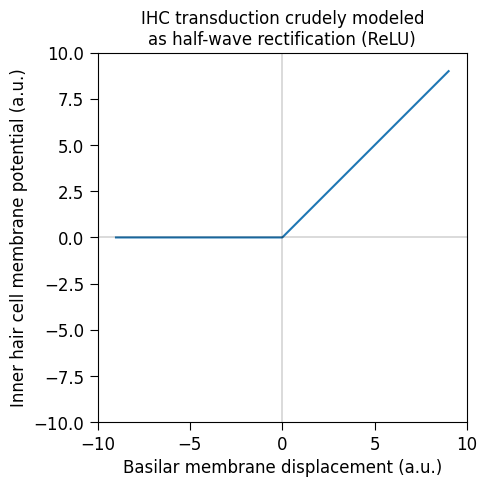

In [18]:
# =============================================================================
# 4. Inner hair cell transduction: half-wave rectification
# =============================================================================
# The basilar membrane vibrates back and forth, so each subband waveform has
# positive and negative pressure/displacement values. Inner hair cells do not
# simply pass this signed vibration onward. They convert mechanical motion into a
# receptor potential and neurotransmitter release. A simple way to capture the
# direction-selective part of this process is half-wave rectification:
#
#   negative values -> 0
#   positive values -> keep them
#
# This is similar to a ReLU activation in neural networks. It is a crude model,
# but it illustrates that biological transduction is nonlinear.
half_wave_rectification = torch.nn.ReLU()

# Make a small toy input to show the mathematical operation of rectification
# before applying it to the actual cochlear subbands.
x = np.arange(-9, 10)
x_rectified = half_wave_rectification(torch.as_tensor(x)).detach().cpu().numpy()

fig, ax = plt.subplots()
ax.plot(x, x_rectified)
ax.axvline(0, color="k", lw=0.2)
ax.axhline(0, color="k", lw=0.2)
ax.axis("square")
utils.format_axes(
    ax,
    xlimits=[-10, 10],
    ylimits=[-10, 10],
    str_xlabel="Basilar membrane displacement (a.u.)",
    str_ylabel="Inner hair cell membrane potential (a.u.)",
    str_title="IHC transduction crudely modeled\nas half-wave rectification (ReLU)",
)
plt.show()

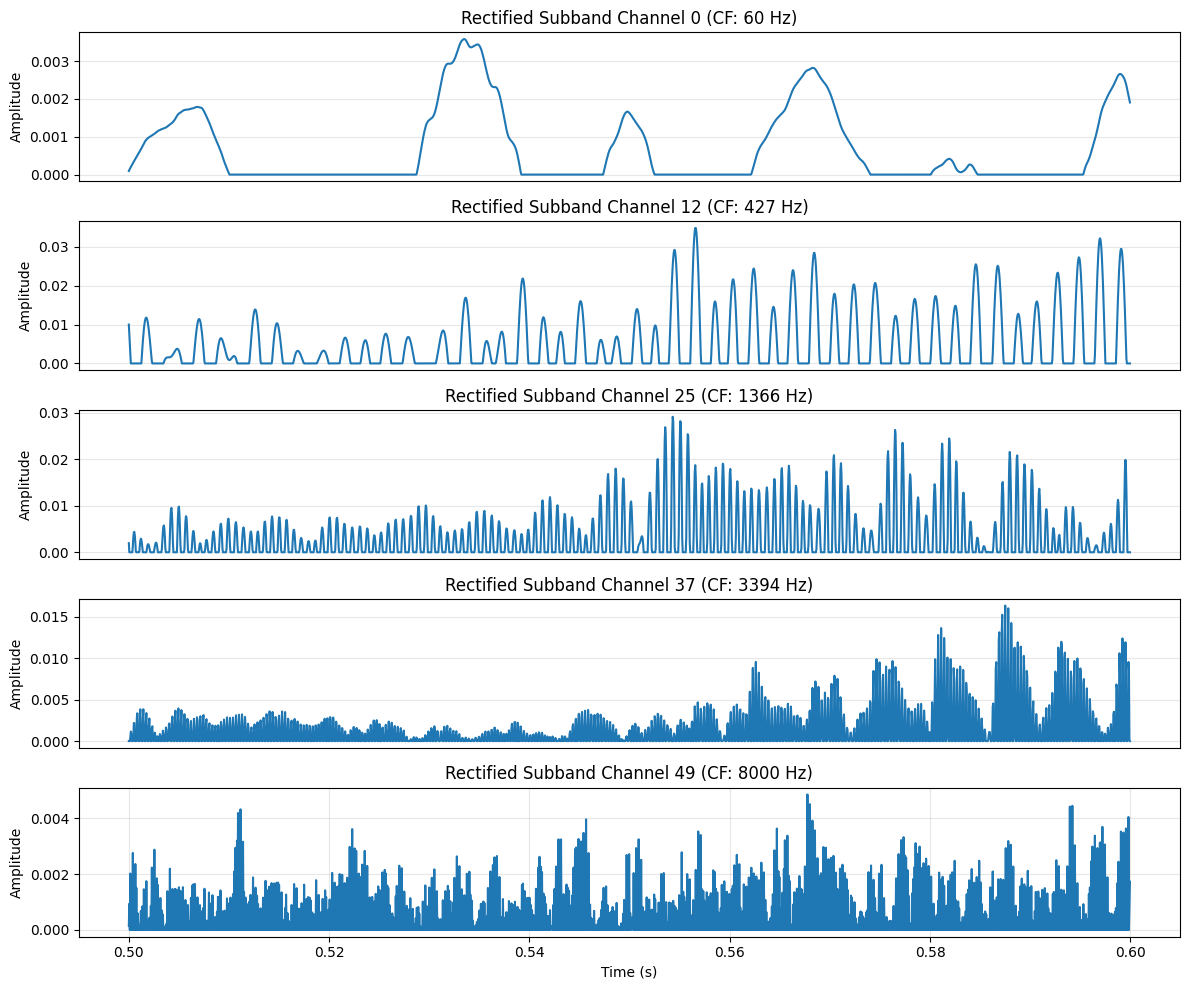

In [19]:
# Apply the same rectifying nonlinearity to every cochlear channel and every time
# sample. In auditory terms, this starts to transform an oscillatory basilar
# membrane response into a one-sided signal more like hair-cell drive.
rectified_subbands = half_wave_rectification(subbands)

# Move to CPU and squeeze to get [num_channels, time] for plotting.
rectified_subbands_np = rectified_subbands.squeeze().detach().cpu().numpy()

# Show the rectified output in the same representative channels. Comparing this
# plot to the previous subband plot demonstrates what was lost: negative half
# cycles no longer appear. What remains is a signal that can drive later firing
# rate estimates.
plt.figure(figsize=(12, 10))
channels_to_view = [0, num_CFs // 4, num_CFs // 2, 3 * num_CFs // 4, num_CFs - 1]

for i, ch in enumerate(channels_to_view):
    plt.subplot(len(channels_to_view), 1, i + 1)
    plt.plot(time_axis[10000:12000], rectified_subbands_np[ch, 10000:12000])
    plt.title(f'Rectified Subband Channel {ch} (CF: {cfs[ch]:.0f} Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    if i < len(channels_to_view) - 1:
        plt.xticks([])

plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

# Simulation of limits of phase-locking with low-pass filters

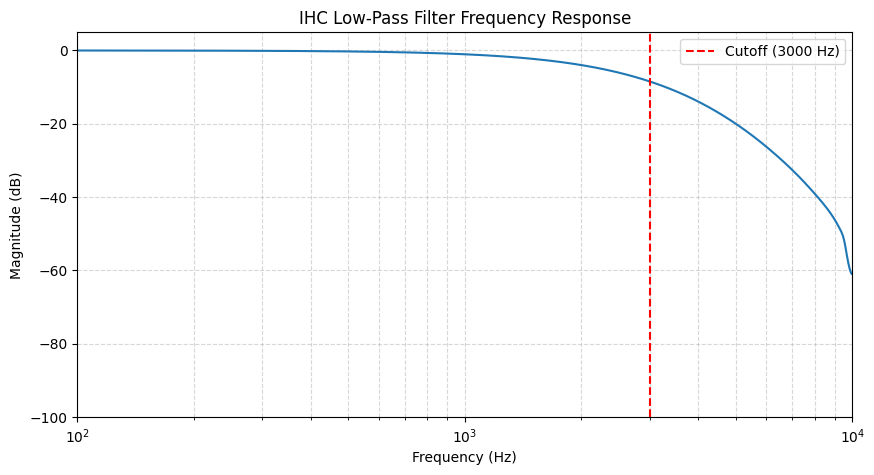

In [20]:
# =============================================================================
# 5. Inner hair cell low-pass filtering: phase-locking limitation
# =============================================================================
# Auditory nerve fibers can synchronize their spikes to the phase of low-frequency
# sounds, but this ability weakens at high frequencies. In a simplified model,
# low-pass filtering the rectified IHC signal removes very fast fluctuations,
# leaving slower envelope-like modulations.
#
# Conceptually:
#   rectification makes the signal one-sided
#   low-pass filtering smooths out rapid fluctuations
# Together, these operations resemble a simple envelope extraction stage.
ihc_lowpass_filter = modules.IHCLowpassFilter(
    sr_input=sample_rate,
    sr_output=sample_rate,
    fir_dur=dur_impulse_response,
    cutoff=phaselock_cutoff,
    order=7,
)

import torch.fft as fft
import matplotlib.pyplot as plt

# Re-initialize the filter explicitly. This duplicates the construction above,
# but it makes the cell self-contained in a notebook setting.
ihc_lowpass_filter = modules.IHCLowpassFilter(
    sr_input=sample_rate,
    sr_output=sample_rate,
    fir_dur=dur_impulse_response,
    cutoff=phaselock_cutoff,
    order=7,
)

# Inspect the low-pass filter just as we inspected the cochlear filters. This
# shows which temporal modulation frequencies are preserved and which are
# attenuated.
lp_fir = ihc_lowpass_filter.fir.detach().cpu().squeeze()

# FFT of the IHC low-pass FIR gives its frequency response.
n_fft_lp = 4096
lp_freq_response = fft.rfft(lp_fir, n=n_fft_lp)
lp_magnitude_db = 20 * torch.log10(torch.abs(lp_freq_response) + 1e-12)

# Frequency axis for the low-pass filter plot.
lp_freqs = torch.linspace(0, sample_rate / 2, lp_magnitude_db.shape[-1])

plt.figure(figsize=(10, 5))
plt.plot(lp_freqs.numpy(), lp_magnitude_db.numpy())

# The dashed vertical line marks the cutoff parameter. Frequencies below this
# are relatively preserved; frequencies far above this are strongly reduced.
plt.axvline(x=phaselock_cutoff, color='r', linestyle='--', label=f'Cutoff ({phaselock_cutoff} Hz)')

plt.xscale('log')
plt.title('IHC Low-Pass Filter Frequency Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.ylim(-100, 5)
plt.xlim(100, sample_rate / 2)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

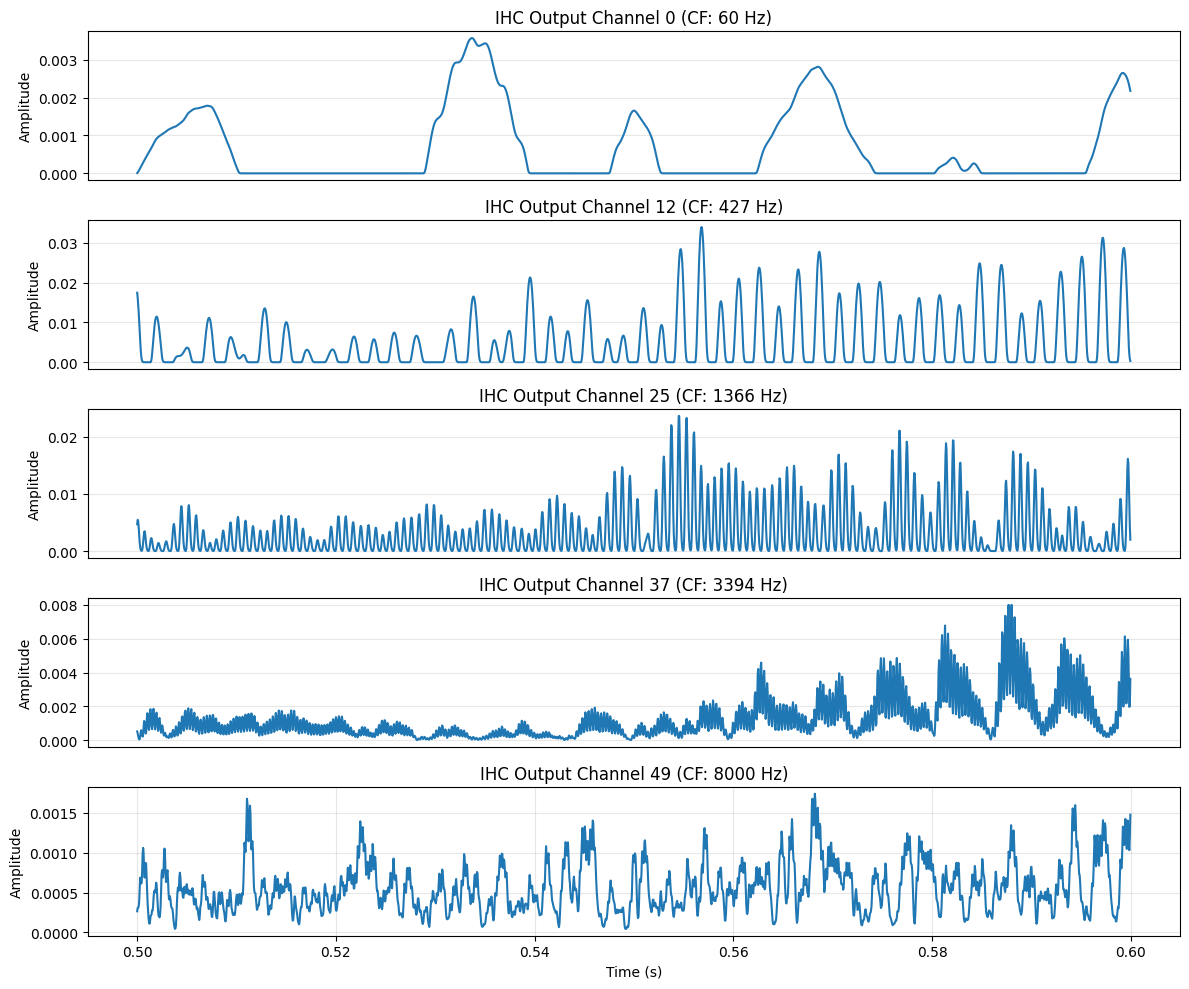

In [21]:
# Apply the IHC low-pass filter to the rectified cochlear subbands. The result is
# a smoothed IHC drive signal for every cochlear channel.
with torch.no_grad():
    ihc_output = ihc_lowpass_filter(rectified_subbands)

ihc_output_np = ihc_output.squeeze().detach().cpu().numpy()

# Plot the IHC output. Compared with the rectified plot, the rapid wiggles should
# be reduced. The remaining signal is closer to a time-varying drive to auditory
# nerve firing.
plt.figure(figsize=(12, 10))
channels_to_view = [0, num_CFs // 4, num_CFs // 2, 3 * num_CFs // 4, num_CFs - 1]

for i, ch in enumerate(channels_to_view):
    plt.subplot(len(channels_to_view), 1, i + 1)
    plt.plot(time_axis[10000:12000], ihc_output_np[ch, 10000:12000])
    plt.title(f'IHC Output Channel {ch} (CF: {cfs[ch]:.0f} Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    if i < len(channels_to_view) - 1:
        plt.xticks([])

plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

# Simulation of auditory nerve rate-level function

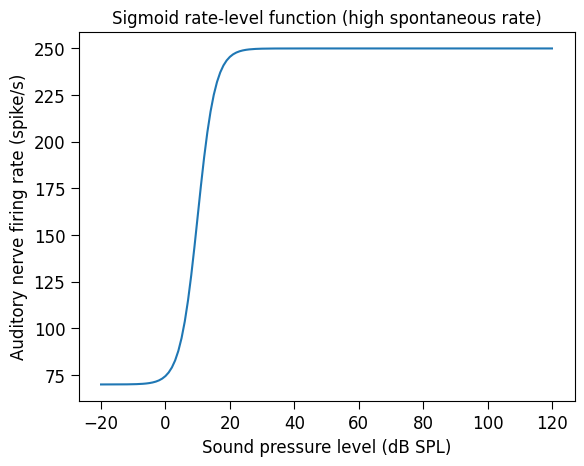

In [22]:
# =============================================================================
# 6. Auditory nerve rate-level functions
# =============================================================================
# The IHC output is still a continuous analog-like signal. The auditory nerve
# communicates with spikes. Before generating spikes, this model first converts
# IHC drive into an instantaneous firing rate in spikes per second.
#
# The mapping from sound level to firing rate is nonlinear:
#   - There is spontaneous firing even without sound.
#   - Firing rate increases as sound level increases.
#   - Firing eventually saturates near a maximum rate.
#
# A sigmoid captures this basic pattern.
fig, ax = plt.subplots()
rate_level_function_hsr = modules.SigmoidRateLevelFunction(
    rate_spont=rate_spont_hsr,
    rate_max=rate_max_hsr,
    threshold=threshold_hsr,
    dynamic_range=dynamic_range_hsr,
    dynamic_range_interval=0.95,
    dtype=torch.float32,
).to(device)

# Make a level axis in dB SPL. dB SPL is a logarithmic scale referenced to
# 20 micropascals, which is conventionally near the threshold of human hearing
# around the most sensitive frequencies.
x_db = np.arange(-20, 121)

# Convert dB SPL to pressure in pascals using:
#   pressure = 20e-6 * 10^(dB_SPL / 20)
# The rate-level function expects linear pressure-like input, not dB directly.
x_pa = 20e-6 * (10 ** (x_db / 20))
x_pa_torch = torch.as_tensor(
    x_pa,
    device=device,
    dtype=torch.float32,
)

# Evaluate the HSR rate-level function. The singleton dimensions [None, None, :]
# make the input match the model's expected [batch, channel, time_or_level] shape.
y_torch = rate_level_function_hsr(x_pa_torch[None, None, :])[0, 0, :]
y = y_torch.detach().cpu().numpy()
ax.plot(x_db, y)
ax = utils.format_axes(
    ax,
    str_xlabel="Sound pressure level (dB SPL)",
    str_ylabel="Auditory nerve firing rate (spike/s)",
    str_title="Sigmoid rate-level function (high spontaneous rate)",
)
plt.show()

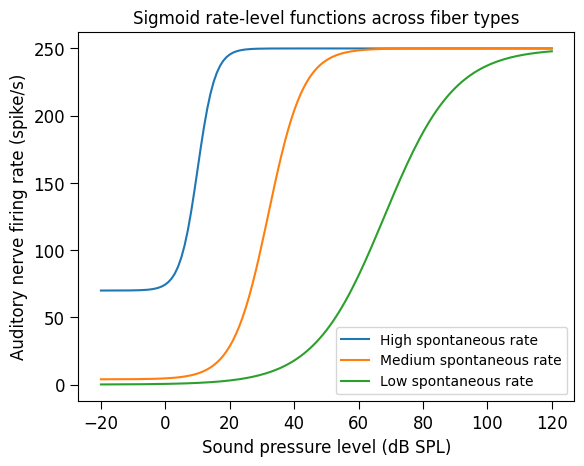

In [23]:
# Now construct and compare the three fiber classes. The point of this plot is to
# show population diversity: different auditory nerve fibers cover different
# parts of the intensity range.
fig, ax = plt.subplots()
rate_level_function_hsr = modules.SigmoidRateLevelFunction(
    rate_spont=rate_spont_hsr,
    rate_max=rate_max_hsr,
    threshold=threshold_hsr,
    dynamic_range=dynamic_range_hsr,
    dynamic_range_interval=0.95,
    dtype=torch.float32,
).to(device)

rate_level_function_msr = modules.SigmoidRateLevelFunction(
    rate_spont=rate_spont_msr,
    rate_max=rate_max_msr,
    threshold=threshold_msr,
    dynamic_range=dynamic_range_msr,
    dynamic_range_interval=0.95,
    dtype=torch.float32,
).to(device)

rate_level_function_lsr = modules.SigmoidRateLevelFunction(
    rate_spont=rate_spont_lsr,
    rate_max=rate_max_lsr,
    threshold=threshold_lsr,
    dynamic_range=dynamic_range_lsr,
    dynamic_range_interval=0.95,
    dtype=torch.float32,
).to(device)

x_db = np.arange(-20, 121)
x_pa = 20e-6 * (10 ** (x_db / 20))
x_pa_torch = torch.as_tensor(
    x_pa,
    device=device,
    dtype=torch.float32,
)

# These curves differ mainly in baseline rate, threshold, and dynamic range.
y_hsr = rate_level_function_hsr(x_pa_torch[None, None, :])[0, 0, :].detach().cpu().numpy()
y_msr = rate_level_function_msr(x_pa_torch[None, None, :])[0, 0, :].detach().cpu().numpy()
ylsr = rate_level_function_lsr(x_pa_torch[None, None, :])[0, 0, :].detach().cpu().numpy()

ax.plot(x_db, y_hsr, label='High spontaneous rate')
ax.plot(x_db, y_msr, label='Medium spontaneous rate')
ax.plot(x_db, ylsr, label='Low spontaneous rate')
ax.legend()
ax = utils.format_axes(
    ax,
    str_xlabel="Sound pressure level (dB SPL)",
    str_ylabel="Auditory nerve firing rate (spike/s)",
    str_title="Sigmoid rate-level functions across fiber types",
)
plt.show()

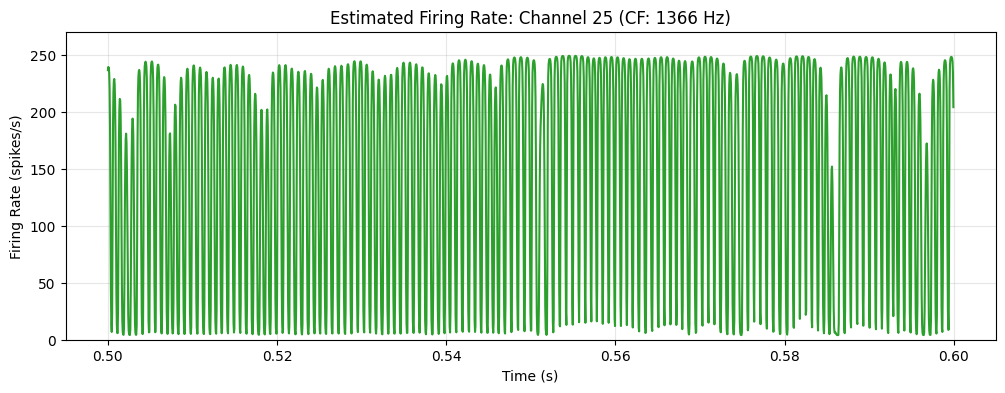

In [24]:
# Select one cochlear channel for a simple time-domain plot of firing rate. A
# mid-frequency channel is often convenient for speech because much speech energy
# is distributed across mid frequencies.
channel_idx = 25

# The rate-level function expects [batch, channel, time]. Depending on the exact
# filter implementation, ihc_output may contain extra singleton dimensions. This
# cleanup keeps the numerical content the same while giving the function the
# shape it expects.
ihc_output_input = ihc_output.squeeze()
if ihc_output_input.ndim == 2:
    ihc_output_input = ihc_output_input.unsqueeze(0)

# Convert IHC output to instantaneous firing rate. Here we use the MSR curve as a
# representative example. A more complete simulation would apply separate HSR,
# MSR, and LSR rate-level functions to generate three rate tensors.
with torch.no_grad():
    firing_rates = rate_level_function_msr(ihc_output_input)

# Convert to NumPy for plotting. The result is a time-varying firing-rate estimate
# for each cochlear channel.
firing_rates_np = firing_rates.squeeze().detach().cpu().numpy()

plt.figure(figsize=(12, 4))
plt.plot(time_axis[10000:12000], firing_rates_np[channel_idx, 10000:12000], color='tab:green')
plt.title(f'Estimated Firing Rate: Channel {channel_idx} (CF: {cfs[channel_idx]:.0f} Hz)')
plt.ylabel('Firing Rate (spikes/s)')
plt.xlabel('Time (s)')
plt.grid(True, alpha=0.3)
plt.ylim(0, rate_max_hsr + 20)
plt.show()

# Simulation of auditory spike trains from firing rates

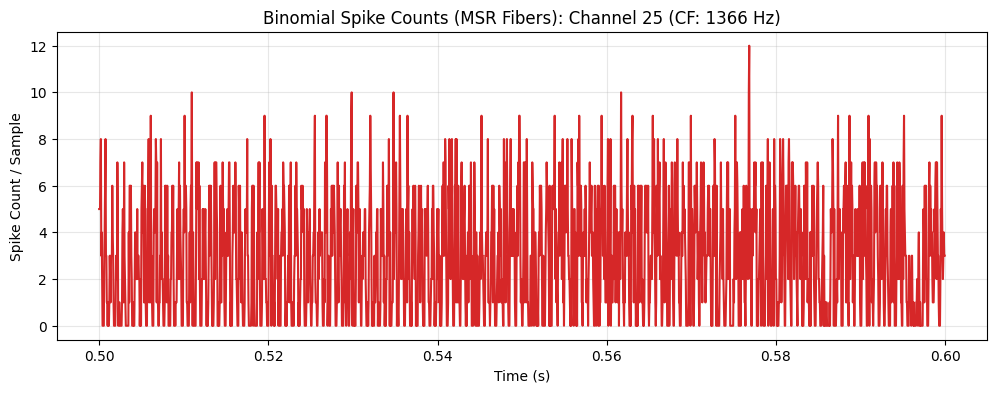

Shape of generated spike counts: torch.Size([1, 3, 50, 40000])


In [25]:
# =============================================================================
# 7. Stochastic auditory nerve spike generation
# =============================================================================
# A firing rate says the expected number of spikes per second, but real auditory
# nerve responses are discrete and variable. This class converts firing rates
# into spike counts using a binomial sampling model.
#
# Intuition:
#   If a fiber has a firing rate of r spikes/s and the sample rate is sr samples/s,
#   then the probability of a spike in one sample is approximately r / sr.
#
# For a population of n similar fibers, the number of spikes in one sample can be
# modeled as a binomial random variable: how many of n fibers fired at that time?


# Create a spike generator. The fiber counts match the HSR, MSR, and LSR
# population sizes defined above. mode='approx' is a good teaching choice because
# it is fast and captures stochastic variability at the population level.

# Initialize the generator on the chosen device. This repeats the construction
# above, but now explicitly moves the module and its buffers to CPU or GPU.
spike_generator = modules.BinomialSpikeGenerator(
    sr=sample_rate,
    mode='approx',
    n_per_channel=[n_fiber_hsr, n_fiber_msr, n_fiber_lsr],
).to(device)

# The spike generator expects a separate dimension for fiber type:
#   [batch, fiber_type, frequency_channel, time]
#
# At this point firing_rates is [batch, frequency_channel, time]. The line below
# duplicates the same firing-rate tensor across three fiber-type channels. This
# keeps the demonstration simple, but note the biological simplification: a full
# implementation would usually compute different rates for HSR, MSR, and LSR
# using their own rate-level functions.
firing_rates_4d = firing_rates.unsqueeze(1).repeat(1, 3, 1, 1)

with torch.no_grad():
    # spike_counts shape: [batch, fiber_type, CF_channel, time]
    # Each value is the number of simulated fibers in that population that fired
    # in that sample.
    spike_counts = spike_generator(firing_rates_4d)

# Move to CPU for plotting.
spike_counts_np = spike_counts.detach().cpu().numpy()

# Plot spike counts for one fiber population and one cochlear channel. The trace
# is noisy because spike generation is random. This variability is not a bug: it
# reflects the probabilistic nature of neural spiking.
plt.figure(figsize=(12, 4))
plt.plot(time_axis[10000:12000], spike_counts_np[0, 0, channel_idx, 10000:12000], color='tab:red')
plt.title(f'Binomial Spike Counts (MSR Fibers): Channel {channel_idx} (CF: {cfs[channel_idx]:.0f} Hz)')
plt.ylabel('Spike Count / Sample')
plt.xlabel('Time (s)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Shape of generated spike counts: {spike_counts.shape}")




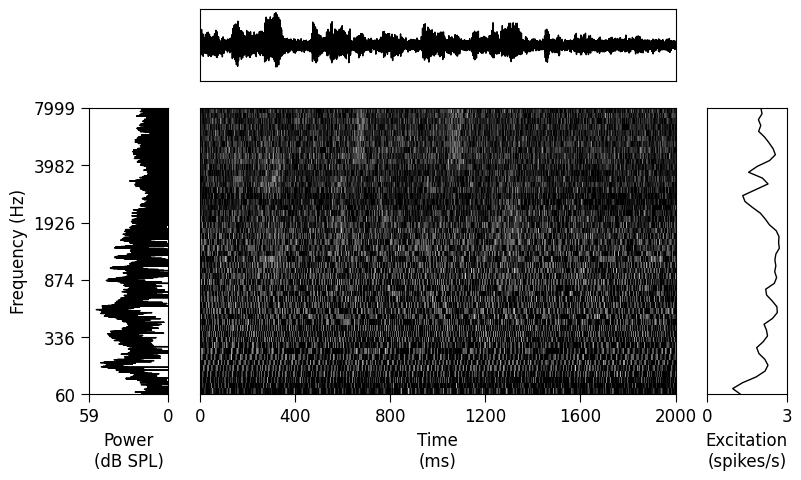

In [26]:
# =============================================================================
# 8. Nervegram visualization
# =============================================================================
# A nervegram is like an auditory spectrogram, but instead of showing acoustic
# energy, it shows modeled auditory nerve activity across cochlear frequency
# channels over time. It is a compact way to visualize what information the model
# sends forward toward the brainstem.

# Select the HSR population, fiber_type index 0, and remove the batch dimension.
# Shape goes from [1, 3, 50, 40000] to [50, 40000].
# Rows correspond to cochlear frequency channels; columns correspond to time.
nervegram_hsr = spike_counts_np[0, 0, :, :]

# Make sure the original acoustic waveform is 1D so it can be plotted above or
# alongside the nervegram. This helps connect the neural representation back to
# the original sound pressure waveform.
waveform_1d = waveform.numpy().squeeze()

fig, ax_arr = utils.make_nervegram_plot(
    waveform=waveform_1d,
    nervegram=nervegram_hsr,
    sr_waveform=sample_rate,
    sr_nervegram=sample_rate,
    cfs=cfs,
)
plt.show()


# The full cochlear model

In [50]:
class CochlearModel(torch.nn.Module):
    def __init__(
        self,
        sr_input=20000,
        sr_output=10000,
        fir_dur=0.05,
        cf_low=80,
        cf_high=8000,
        num_cfs=100,
        bw_mult=1.0,
        cutoff=3000,
        threshold=0.0,
        dynamic_range=80.0,
        rate_spont=0.0,
        rate_max=250.0,
        n_hsr=384,
        dtype=torch.float32,
    ):
        """
        Simple cochlear model in PyTorch.

        Args
        ----
        sr_input (int): sampling rate of the input sound waveform
        sr_output (int): sampling rate of the output representation
        fir_dur (float): duration of finite impulse responses for filtering (s)
        cfs (np.ndarray): characteristic frequencies of the cochlear filters (Hz)
        bw_mult (float): scaling factor applied to cochlear filter bandwidths
        threshold (float): absolute threshold of auditory nerve fibers (dB SPL)
        dynamic_range (float): auditory nerve fiber dynamic range (dB)
        dtype (torch.dtype): datatype for internal intensors and inputs
        """
        super().__init__()
        self.sr_input = sr_input
        self.sr_output = sr_output
        self.cfs = utils.erbspace(cf_low, cf_high, num_cfs),
        self.cochlear_filterbank = modules.GammatoneFilterbank(
            sr=sr_input,
            fir_dur=fir_dur,
            cfs=self.cfs,
            dtype=dtype,
            bw_mult=bw_mult,
        )
        self.half_wave_rectification = torch.nn.ReLU()
        self.ihc_lowpass_filter = modules.IHCLowpassFilter(
            sr_input=sr_input,
            sr_output=sr_output,
            fir_dur=fir_dur,
            cutoff=cutoff,
            order=7,
        )
        self.rate_level_function = modules.SigmoidRateLevelFunction(
            rate_spont=rate_spont,
            rate_max=rate_max,
            threshold=threshold,
            dynamic_range=dynamic_range,
            dynamic_range_interval=0.95,
            dtype=dtype,
        )
        self.spike_generator = modules.BinomialSpikeGenerator(
            sr=sr_output,
            mode='approx',
            n_per_channel=[n_hsr],
        )

    def forward(self, x):
        """
        Run the cochlear model on a batch of input sound waveforms.

        Args
        ----
        x (torch.Tensor): input sound waveforms with shape [batch, time]

        Returns
        -------
        x (torch.Tensor): output of cochlear model with shape [batch, freq, time]
        """
        x = self.cochlear_filterbank(x)
        x = self.half_wave_rectification(x)
        x = self.ihc_lowpass_filter(x)
        x = self.half_wave_rectification(x)
        x = self.rate_level_function(x)
        x = self.spike_generator(x.unsqueeze(dim=-1))
        return x


cochlear_model = CochlearModel()


In [41]:
nervegram_output = cochlear_model(waveform)
print(f"{nervegram_output.shape=}, {nervegram_output.shape=}")

nervegram_output.shape=torch.Size([1, 100, 20000, 1]), nervegram_output.shape=torch.Size([1, 100, 20000, 1])



### Conceptual summary
# =============================================================================
#### By the end of the script, the acoustic waveform has been transformed through a simplified auditory-processing cascade:
#
#### 1. The gammatone filterbank separates the sound into cochlear frequency bands.
#### 2. Half-wave rectification approximates the directional nonlinear transduction of inner hair cells.
#### 3. Low-pass filtering approximates limits of phase locking and produces a smoother hair-cell drive signal.
#### 4. Sigmoid rate-level functions convert drive into auditory-nerve firing rates with spontaneous activity, thresholds, dynamic ranges, and saturation.
#### 5. Binomial spike generation converts continuous rates into stochastic spike counts for populations of nerve fibers.
#### 6. The nervegram displays the resulting modeled neural activity over time and cochlear frequency.
#
#### The main teaching point is that early hearing is not just a Fourier transform. It is a cascade of frequency-selective filtering, nonlinear transduction, temporal smoothing, level-dependent saturation, population diversity, and stochastic neural encoding.

# Simulation of the impaired auditory periphery

# 0. Simulation of the healthy cochlea

In [51]:
lowest_CF = 60
highest_CF = 8000
num_CFs = 3000
filter_bandwidth = 1
dur_impulse_response = 0.05
phaselock_cutoff = 3000

rate_spont = 70.0
rate_max = 250.0
threshold = 0.0
dynamic_range = 20.0
n_fiber = 10

dynamic_range_interval = 0.95

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# initiate the cochlea model
cochlear_model_normal = CochlearModel(
    sr_input=20000,
    sr_output=10000,
    fir_dur=0.05,
    cf_low=lowest_CF,
    cf_high=highest_CF,
    num_cfs=num_CFs,
    bw_mult=filter_bandwidth,
    cutoff=phaselock_cutoff,
    threshold=threshold,
    dynamic_range=dynamic_range,
    rate_spont=rate_spont,
    rate_max=rate_max,
    n_hsr=n_fiber,
)

## 1. Simulation of elevated threshold and reduced frequency tuning (i.e., braod auditory filters) from OHC loss

In [52]:
lowest_CF = 60
highest_CF = 8000
num_CFs = 3000
filter_bandwidth = 2 # broad auditory filter simulated by changing the bandwith scaling parameter
dur_impulse_response = 0.05
phaselock_cutoff = 3000

## Elevated threshold and reduced dynamic range simulated via modifying the rate-level function parameters
rate_spont = 70.0
rate_max = 250.0
threshold = 50.0
dynamic_range = 10.0
n_fiber = 10

dynamic_range_interval = 0.95

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# initiate the cochlea model
cochlear_model_ohc_loss = CochlearModel(
    sr_input=20000,
    sr_output=10000,
    fir_dur=0.05,
    cf_low=lowest_CF,
    cf_high=highest_CF,
    num_cfs=num_CFs,
    bw_mult=filter_bandwidth,
    cutoff=phaselock_cutoff,
    threshold=threshold,
    dynamic_range=dynamic_range,
    rate_spont=rate_spont,
    rate_max=rate_max,
    n_hsr=n_fiber,
)

## 2. Simulation of auditory synaptopathy (loss of nerve fibers)

In [53]:
lowest_CF = 60
highest_CF = 8000
num_CFs = 3000
filter_bandwidth = 1
dur_impulse_response = 0.05
phaselock_cutoff = 3000

rate_spont = 70.0
rate_max = 250.0
threshold = 0.0
dynamic_range = 20.0
n_fiber = 1 # reduce the number of simulated auditory fibers

dynamic_range_interval = 0.95

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# initiate the cochlea model
cochlear_model_synaptopathy = CochlearModel(
    sr_input=20000,
    sr_output=10000,
    fir_dur=0.05,
    cf_low=lowest_CF,
    cf_high=highest_CF,
    num_cfs=num_CFs,
    bw_mult=filter_bandwidth,
    cutoff=phaselock_cutoff,
    threshold=threshold,
    dynamic_range=dynamic_range,
    rate_spont=rate_spont,
    rate_max=rate_max,
    n_hsr=n_fiber,
)

# 3. Degraded temporal coding and reduced phase locking following hearing loss

In [54]:
lowest_CF = 60
highest_CF = 8000
num_CFs = 3000
filter_bandwidth = 1
dur_impulse_response = 0.05
phaselock_cutoff = 100 # reduced phase locking cutoff

rate_spont = 70.0
rate_max = 250.0
threshold = 0.0
dynamic_range = 20.0
n_fiber = 10

dynamic_range_interval = 0.95

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# initiate the cochlea model
cochlear_model_phaselocking = CochlearModel(
    sr_input=20000,
    sr_output=10000,
    fir_dur=0.05,
    cf_low=lowest_CF,
    cf_high=highest_CF,
    num_cfs=num_CFs,
    bw_mult=filter_bandwidth,
    cutoff=phaselock_cutoff,
    threshold=threshold,
    dynamic_range=dynamic_range,
    rate_spont=rate_spont,
    rate_max=rate_max,
    n_hsr=n_fiber,
)

In [55]:
## Obtain the cochlear representation from the three different cases:
nervegram_normal_cochlea = cochlear_model_normal(waveform)
nervegram_ohc_loss = cochlear_model_ohc_loss(waveform)
nervegram_synaptopathy = cochlear_model_synaptopathy(waveform)
nervegram_phaselocking = cochlear_model_phaselocking(waveform)

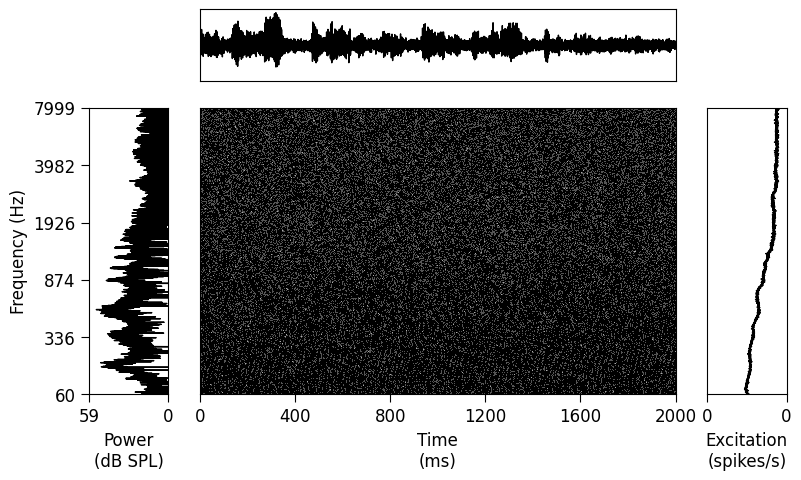

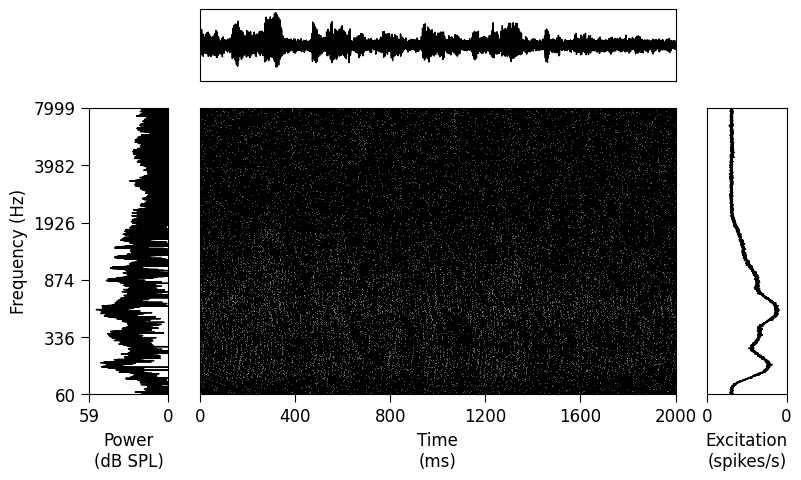

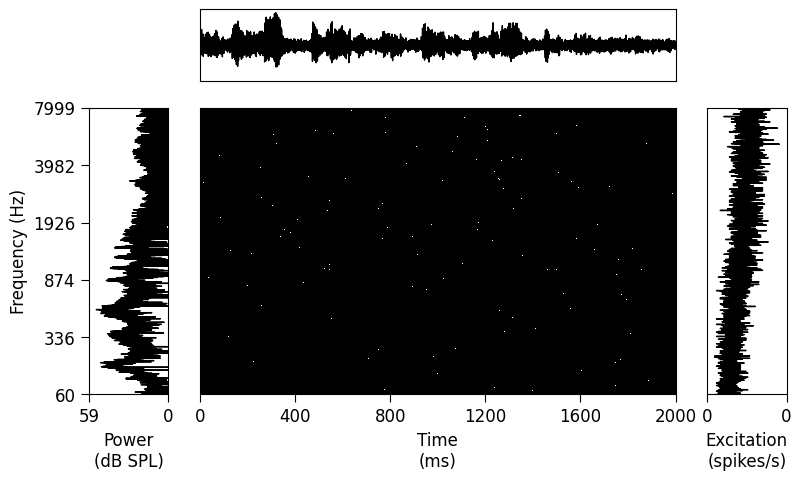

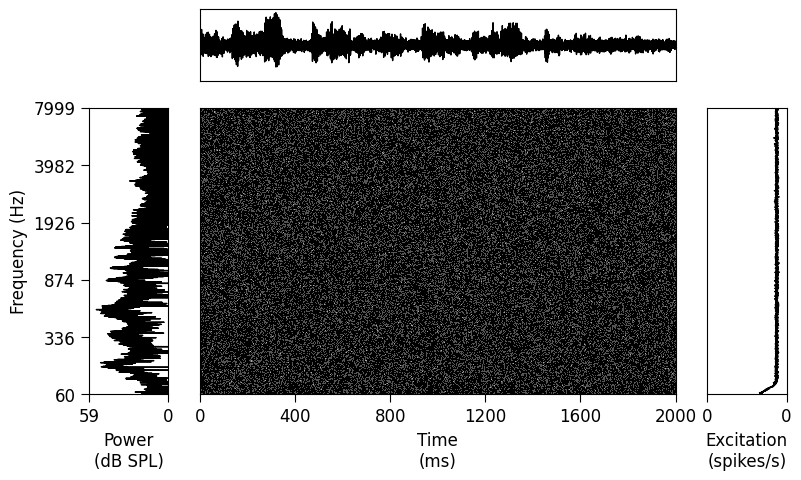

In [57]:
# =============================================================================
# 8. Nervegram visualization
# =============================================================================
cfs = utils.erbspace(lowest_CF, highest_CF, num_CFs)
waveform_1d = waveform.numpy().squeeze()

fig, ax_arr = utils.make_nervegram_plot(
    waveform=waveform_1d,
    nervegram=nervegram_normal_cochlea[0,:,:,0].numpy(),
    sr_waveform=20000,
    sr_nervegram=10000,
    cfs=cfs,
)
plt.show()

fig, ax_arr = utils.make_nervegram_plot(
    waveform=waveform_1d,
    nervegram=nervegram_ohc_loss[0,:,:,0].numpy(),
    sr_waveform=20000,
    sr_nervegram=10000,
    cfs=cfs,
)
plt.show()

fig, ax_arr = utils.make_nervegram_plot(
    waveform=waveform_1d,
    nervegram=nervegram_synaptopathy[0,:,:,0].numpy(),
    sr_waveform=20000,
    sr_nervegram=10000,
    cfs=cfs,
)
plt.show()

fig, ax_arr = utils.make_nervegram_plot(
    waveform=waveform_1d,
    nervegram=nervegram_phaselocking[0,:,:,0].numpy(),
    sr_waveform=20000,
    sr_nervegram=10000,
    cfs=cfs,
)
plt.show()
